In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from utils import InMemDataLoader, get_device, draw_images

In [ ]:
device = get_device()
print(device)

In [ ]:
IMG_WIDTH = 48

CLEAN_DATASET_FILENAME = "teddy_bear.npy"
CLEAN_DATASET_PATH = f"clean_datasets/{CLEAN_DATASET_FILENAME}"

bear_img = np.load(CLEAN_DATASET_PATH).reshape(-1, IMG_WIDTH, IMG_WIDTH)
print(bear_img.shape)

BATCH_SIZE = 128
NO_OF_BATCHES = 305

no_of_full_batches = len(bear_img) // BATCH_SIZE
assert NO_OF_BATCHES <= no_of_full_batches, (
    f"{NO_OF_BATCHES=}, {no_of_full_batches=}. Too few images in dataset {CLEAN_DATASET_PATH}!"
)

bear_img = bear_img[: NO_OF_BATCHES * BATCH_SIZE]
bear_img = (bear_img / 255.0 - 0.5) / 0.5

data_loader = InMemDataLoader(
    [(img,) for img in bear_img], batch_size=BATCH_SIZE, shuffle=True
).to(device)
print(
    f"Taken {NO_OF_BATCHES * BATCH_SIZE} / {no_of_full_batches * BATCH_SIZE} = {100 * NO_OF_BATCHES / no_of_full_batches:.2f}%"
)

In [5]:
class Reshape(nn.Module):
    def __init__(self, shape):
        super().__init__()
        self.shape = shape

    def forward(self, x):
        return torch.reshape(x, (x.size(0), *self.shape))


class Generator(nn.Module):
    def __init__(self, in_dim=100, out_dim=(IMG_WIDTH, IMG_WIDTH)):
        super(Generator, self).__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim

        self.layers = nn.Sequential(
            nn.Linear(in_dim, 128 * IMG_WIDTH * IMG_WIDTH),
            nn.BatchNorm1d(128 * IMG_WIDTH * IMG_WIDTH),
            nn.LeakyReLU(),
            Reshape((128, IMG_WIDTH, IMG_WIDTH)),
            nn.ConvTranspose2d(128, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=5, padding=2),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.layers(x)


class Discriminator(nn.Module):
    def __init__(self, in_dim=(IMG_WIDTH, IMG_WIDTH), out_dim=1):
        super(Discriminator, self).__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim

        self.layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.layers(x)

In [6]:
def generator_loss(DG, eps=1e-6):
    return -1 * torch.mean(torch.log(DG + eps))


def discriminator_loss(DR, DG, eps=1e-6):
    return -1 * (torch.mean(torch.log(DR + eps)) + torch.mean(torch.log(1 - DG + eps)))

In [7]:
z_dim = 100

G = Generator(in_dim=z_dim).to(device)
D = Discriminator().to(device)

G_optimizer = optim.Adam(G.parameters(), lr=0.0005)
D_optimizer = optim.Adam(D.parameters(), lr=0.0005)

In [ ]:
for i in range(10000):
    G_loss_acc, D_loss_acc = 0.0, 0.0

    G.train()
    D.train()
    for (x,) in data_loader:
        x = x.float().reshape(x.size(0), 1, IMG_WIDTH, IMG_WIDTH).to(device)

        z = torch.randn(x.size(0), z_dim).to(device)
        x_fake = G(z)
        x_fake_detached = x_fake.detach()

        G_loss = generator_loss(D(x_fake))

        G_optimizer.zero_grad()
        G_loss.backward()
        G_optimizer.step()

        D_loss = discriminator_loss(D(x), D(x_fake_detached))

        D_optimizer.zero_grad()
        D_loss.backward()
        D_optimizer.step()

        G_loss_acc += G_loss.item() * len(x)
        D_loss_acc += D_loss.item() * len(x)

    if i % 10 == 0:
        G.eval()
        with torch.no_grad():
            z = torch.randn(10, z_dim).to(device)
            x_gen = G(z).cpu()

            rows, cols = 1, 10
            fig, axes = plt.subplots(rows, cols, figsize=(cols, 1.5 * rows))
            fig.suptitle(
                f"Epoch: {i}\n Generator loss: {G_loss_acc / len(data_loader):.4f} Discriminator loss: {D_loss_acc / len(data_loader):.4f}"
            )
            for row in range(rows):
                for col in range(cols):
                    axes[col].imshow(x_gen[row * cols + col].view(IMG_WIDTH, IMG_WIDTH))
                    axes[col].axis("off")
            plt.show()
            plt.close(fig)

        torch.save(G.state_dict(), f"models/Gen_2_{i}.model")
        torch.save(D.state_dict(), f"models/Dis_2_{i}.model")
        torch.save(G.state_dict(), "models/Gen.model")
        torch.save(D.state_dict(), "models/Dis.model")


In [ ]:
G.load_state_dict(torch.load("models/Gen.model", map_location=torch.device(device)))

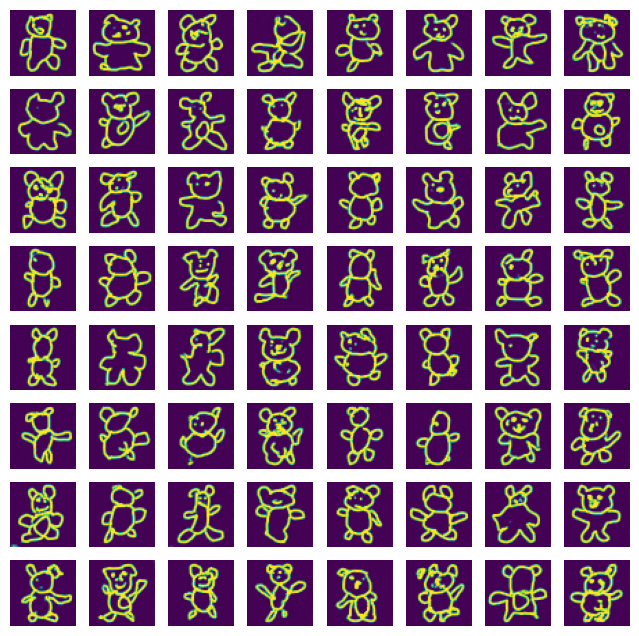

In [10]:
G.eval()

with torch.no_grad():
    z = torch.randn(8 * 8, z_dim).to(device)
    x_gen = G(z).view(-1, IMG_WIDTH, IMG_WIDTH).cpu()

draw_images(x_gen, 8, 8)